In [1]:
import pandas as pd
import numpy as np
import sys
import os
import importlib

sys.path.append(os.path.abspath(".."))

import src.utils.eda as eda
import src.utils.create_meta_features as cmf

In [2]:
# l1_tr_df
importlib.reload(cmf)
tr_df, test_df = cmf.create_meta_features([37], "base", fe_version=12, scale=False)
tr_df.to_parquet("../artifacts/features/l1/l1_tr_df9.parquet", index=False)
test_df.to_parquet("../artifacts/features/l1/l1_test_df9.parquet", index=False)

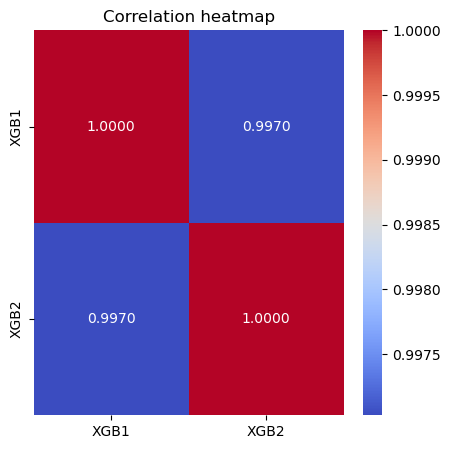

In [4]:
# Check correlation between prediction outputs
importlib.reload(eda)
# RFC, MLP, LogReg, XGB, LGBM
oof1 = np.load("../artifacts/preds/base/oof_single_28.npy")
oof2 = np.load("../artifacts/preds/base/oof_single_30.npy")
oof3 = np.load("../artifacts/preds/base/oof_single_38.npy")
oof4 = np.load("../artifacts/preds/base/oof_single_28.npy")
oof5 = np.load("../artifacts/preds/base/oof_single_25.npy")

oof_list = [oof1, oof2]

oof_array = np.stack(oof_list, axis=1)

oof_df = pd.DataFrame(
    oof_array,
    columns=["XGB1", "XGB2"])

eda.show_corr_heatmap(oof_df)

(750000,)
(750000,)
(750000,)


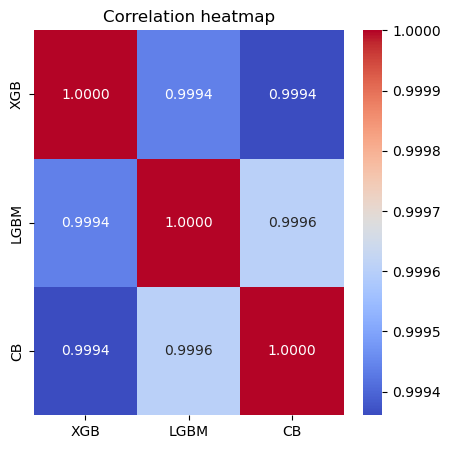

In [3]:
# Check correlation between prediction outputs
importlib.reload(eda)
# RFC, MLP, LogReg, XGB, LGBM
oof22 = np.load("../artifacts/preds/l1/oof_single_22.npy")
oof25 = np.load("../artifacts/preds/l1/oof_single_25.npy")
oof28 = np.load("../artifacts/preds/l1/oof_single_28.npy")

oof_list = [oof22, oof25, oof28]

for oof in oof_list:
    print(oof.shape)

residual_array = np.stack(oof_list, axis=1)

residual_df = pd.DataFrame(
    residual_array,
    columns=["XGB", "LGBM", "CB"])

eda.show_corr_heatmap(residual_df)